In [ ]:
!pip -q install -U "sentence-transformers>=3.0.0" datasets accelerate bitsandbytes transformers

In [ ]:
import os, random, math
import numpy as np
import pandas as pd

from scipy.stats import spearmanr
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

import torch

from datasets import load_dataset, Dataset, DatasetDict
from transformers import BitsAndBytesConfig, EarlyStoppingCallback
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

from sentence_transformers import SentenceTransformer, models
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from sentence_transformers.losses import MultipleNegativesRankingLoss
from sentence_transformers.training_args import SentenceTransformerTrainingArguments
from sentence_transformers.trainer import SentenceTransformerTrainer

from itertools import islice

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

### Bi-encoders VS cross-encoders

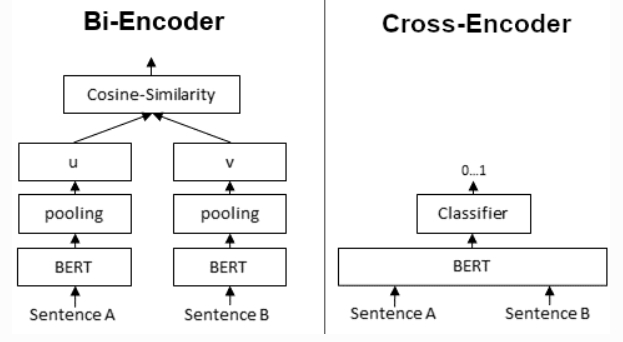

### Symmetric VS Assymmetric

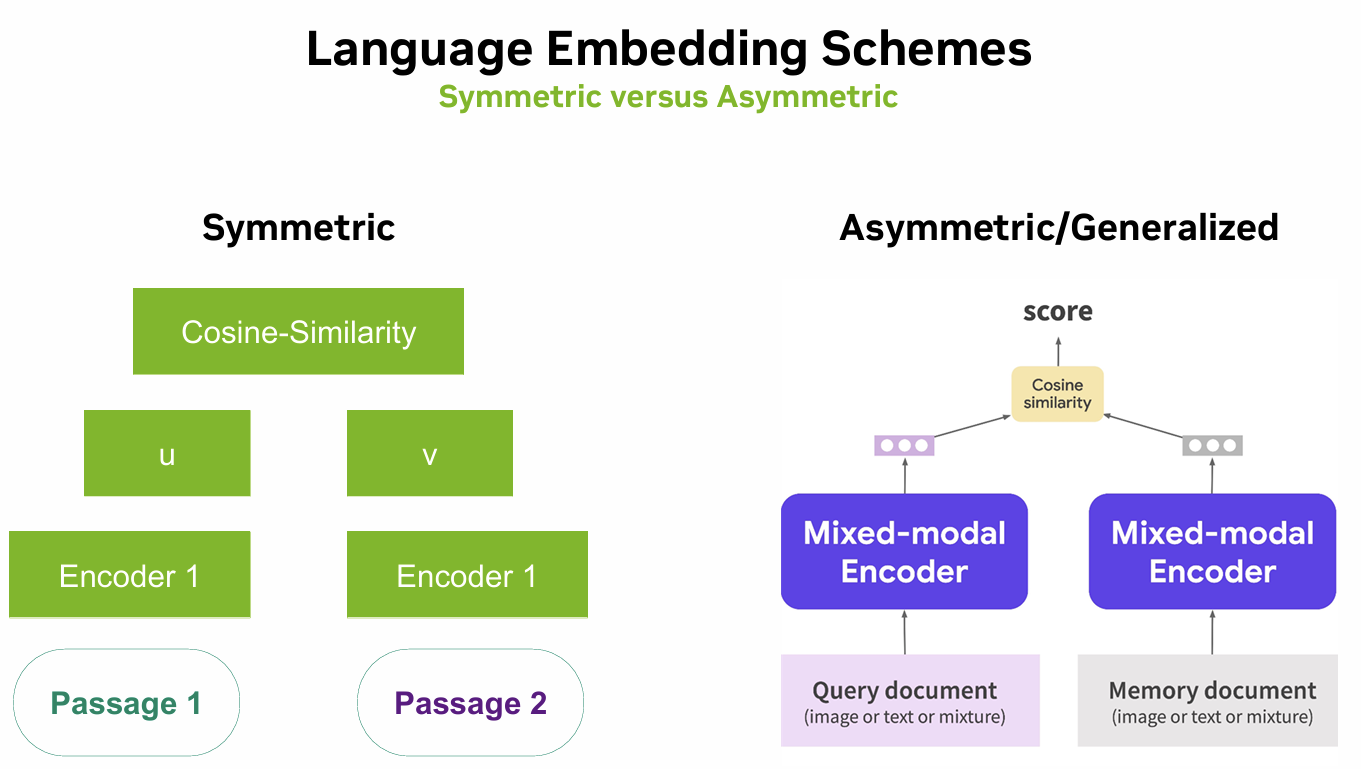

### Утилиты для обучения

In [ ]:
def build_st_4bit(model_name: str, max_seq_length=256):
    compute_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=compute_dtype,
    )

    transformer = models.Transformer(
        model_name,
        max_seq_length=max_seq_length,
        model_args={
            "quantization_config": bnb_config,
            "device_map": "auto",
            "trust_remote_code": True,
        },
    )

    pooling = models.Pooling(transformer.get_word_embedding_dimension(), pooling_mode="mean")
    st = SentenceTransformer(modules=[transformer, pooling])
    return st

In [ ]:
def apply_qlora(st_model, r=16, alpha=32, dropout=0.05, target_modules=None, gradient_checkpointing=True):
    if target_modules is None:
        target_modules = ["query", "key", "value", "dense"]

    transformer = st_model[0]
    base = transformer.auto_model

    if gradient_checkpointing and hasattr(base, "gradient_checkpointing_enable"):
        base.gradient_checkpointing_enable()

    # для обучения нужно отключить cache
    if hasattr(base, "config"):
        base.config.use_cache = False

    base = prepare_model_for_kbit_training(base)

    lora_config = LoraConfig(
        task_type=TaskType.FEATURE_EXTRACTION,
        r=r,
        lora_alpha=alpha,
        lora_dropout=dropout,
        bias="none",
        target_modules=target_modules,
    )

    transformer.auto_model = get_peft_model(base, lora_config)
    transformer.auto_model.print_trainable_parameters()
    return st_model

In [ ]:
def e5_query(text: str) -> str:
    return f"query: {text}"

def e5_passage(text: str) -> str:
    return f"passage: {text}"

### Загрузим данные

In [ ]:
ds = load_dataset("nyuuzyou/9111-questions", split="train", streaming=True)
print(ds)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


IterableDataset({
    features: ['id', 'title', 'description', 'answers'],
    num_shards: 3
})


In [ ]:
sample = list(islice(ds, 10_000))
print(len(sample))
print(sample[0].keys())

10000
dict_keys(['id', 'title', 'description', 'answers'])


In [ ]:
ds = Dataset.from_list(sample)

In [ ]:
tmp = ds.train_test_split(test_size=0.2, seed=SEED)
tmp2 = tmp["test"].train_test_split(test_size=0.5, seed=SEED)

ds_splits = DatasetDict({
    "train": tmp["train"],
    "dev": tmp2["train"],
    "test": tmp2["test"],
})
ds_splits

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'description', 'answers'],
        num_rows: 8000
    })
    dev: Dataset({
        features: ['id', 'title', 'description', 'answers'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['id', 'title', 'description', 'answers'],
        num_rows: 1000
    })
})

### Подготовка разметки

In [ ]:
def make_query(title, description):
    title = (title or "").strip()
    description = (description or "").strip()
    if description:
        return f"{title}\n\n{description}".strip()
    return title.strip()

In [ ]:
MIN_ANSWER_CHARS = 80

def is_lawyer_status(status):
    if status is None:
        return False
    s = str(status).lower()
    return ("юрист" in s) or ("lawyer" in s) or ("адвокат" in s)

def normalize_rating(r):
    try:
        if r is None:
            return 0.0
        return float(r)
    except:
        return 0.0

def clean_text(t):
    if t is None:
        return ""
    t = str(t).strip()
    t = " ".join(t.split())
    return t

def rank_answers(answers):
    if answers is None:
        return []
    ranked = []
    for a in answers:
        if not isinstance(a, dict):
            continue
        text = clean_text(a.get("text"))
        if len(text) < MIN_ANSWER_CHARS:
            continue
        status = a.get("status")
        rating = normalize_rating(a.get("rating"))
        lawyer = 1 if is_lawyer_status(status) else 0
        ranked.append((lawyer, rating, len(text), text, a))

    # сортируем по: lawyer desc, rating desc, length desc
    ranked.sort(key=lambda x: (x[0], x[1], x[2]), reverse=True)
    return ranked

def select_positive_and_semi_hard(answers):
    ranked = rank_answers(answers)
    if len(ranked) == 0:
        return None, None
    pos_text = ranked[0][3]
    semi_text = ranked[1][3] if len(ranked) > 1 else None  # semi-hard = другой (хуже top-1) ответ в том же вопросе
    return pos_text, semi_text

In [ ]:
cols = ds_splits["train"].column_names
print(cols)

TITLE_COL = "title"
DESC_COL = "description"
ANSWERS_COL = "answers"

def preprocess_example(x, idx=None):
    title = x.get(TITLE_COL, "")
    desc  = x.get(DESC_COL, "")
    answers = x.get(ANSWERS_COL, None)

    query = make_query(title, desc)
    pos, semi = select_positive_and_semi_hard(answers)

    return {
        "qid": x.get("id", idx if idx is not None else None),
        "title": clean_text(title),
        "description": clean_text(desc),
        "query": query,
        "positive": pos,
        "semi_hard": semi,
        "has_pos": pos is not None,
    }

def preprocess_split(split_name):
    data = ds_splits[split_name]
    rows = []
    for i, x in enumerate(data):
        rows.append(preprocess_example(x, idx=i))
    d = Dataset.from_list(rows)
    d = d.filter(lambda r: r["has_pos"] and (r["query"] is not None) and (len(r["query"].strip()) > 0))
    return d

base_train = preprocess_split("train")
base_dev   = preprocess_split("dev")
base_test  = preprocess_split("test")

len(base_train), base_train[0]

['id', 'title', 'description', 'answers']


Filter:   0%|          | 0/8000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

(7813,
 {'qid': 11468,
  'title': 'Есть ли риски, если собственники имеют детей, не прописанных в квартире?',
  'description': 'ЧТО нужно проверить и на что обратить внимание при покупке такой квартиры. Квартира была приватизированна в 93 г. на 4 х человек (отец, мать, сын, невестка) равными долями. Все прописаны в квартире. В 98 м и 99 годах у сына и невестки родились дети, они также прописаны в квартире. Отец+мать и сын+невестка+дети расселяются в 2 квартиры. Есть ли риски, если собственники имеют детей, не прописанных в квартире?',
  'query': 'Есть ли риски, если собственники имеют детей, не прописанных в квартире?\n\nЧТО нужно проверить и на что обратить внимание при покупке такой квартиры. Квартира была приватизированна в 93 г. на 4 х человек (отец, мать, сын, невестка) равными долями. Все прописаны в квартире.  В 98 м и 99 годах у сына и невестки родились дети, они также прописаны в квартире. Отец+мать и сын+невестка+дети расселяются в 2 квартиры. Есть ли риски, если собственники

In [ ]:
def build_title_nn_index(dataset: Dataset, n_neighbors=10):
    titles = [r["title"] for r in dataset]
    vectorizer = TfidfVectorizer(min_df=2, max_features=50_000, ngram_range=(1,2))
    X = vectorizer.fit_transform(titles)
    nn = NearestNeighbors(n_neighbors=min(n_neighbors, len(titles)), metric="cosine")
    nn.fit(X)
    return vectorizer, nn, X

In [ ]:
vec, nn, X_train_titles = build_title_nn_index(base_train, n_neighbors=10)

In [ ]:
def pick_hard_negative_from_similar_title(i, dataset: Dataset, vec, nn, X_titles):
    # ищем ближайших соседей, пропускаем самого себя
    distances, indices = nn.kneighbors(X_titles[i], return_distance=True)
    for j in indices[0]:
        if j == i:
            continue
        cand = dataset[int(j)]
        # берем positive-соседа как hard negative passage
        if cand["positive"] is not None and len(cand["positive"]) >= MIN_ANSWER_CHARS:
            return cand["positive"], cand["qid"]
    return None, None

### Hard negatives по “похожему заголовку” (TF‑IDF по title)


Hard negative: ответ из похожего по теме вопроса (похожий title), но другой записи.

Мы возьмём positive от ближайшего соседа по TF‑IDF (быстро и детерминированно).

In [ ]:
def make_pairs_for_eval(dataset: Dataset, split_name: str, vec=None, nn=None, X_titles=None):
    rows = []
    n = len(dataset)

    for i in range(n):
        ex = dataset[i]
        q = e5_query(ex["query"])

        # positive
        rows.append({
            "text1": q,
            "text2": e5_passage(ex["positive"]),
            "score": 1.0,
            "pair_type": "positive",
            "qid": ex["qid"],
        })

        # semi-hard (внутри того же вопроса)
        if ex.get("semi_hard"):
            rows.append({
                "text1": q,
                "text2": e5_passage(ex["semi_hard"]),
                "score": 0.5,
                "pair_type": "semi_hard",
                "qid": ex["qid"],
            })

        # hard negative (похожий title)
        if vec is not None and nn is not None and X_titles is not None:
            hn_text, hn_qid = pick_hard_negative_from_similar_title(i, dataset, vec, nn, X_titles)
            if hn_text:
                rows.append({
                    "text1": q,
                    "text2": e5_passage(hn_text),
                    "score": 0.0,
                    "pair_type": "hard_negative_sim_title",
                    "qid": ex["qid"],
                    "hn_qid": hn_qid
                })

        # random negative
        j = random.randrange(0, n)
        while j == i:
            j = random.randrange(0, n)
        rn = dataset[j]["positive"]
        rows.append({
            "text1": q,
            "text2": e5_passage(rn),
            "score": 0.0,
            "pair_type": "random_negative",
            "qid": ex["qid"],
            "rn_qid": dataset[j]["qid"]
        })

    return Dataset.from_list(rows)

pairs_train = make_pairs_for_eval(base_train, "train", vec=vec, nn=nn, X_titles=X_train_titles)
# для dev/test строим отдельные индексы (чтобы hard-neg был внутри соответствующего split)
vec_dev, nn_dev, X_dev_titles = build_title_nn_index(base_dev, n_neighbors=10)
vec_test, nn_test, X_test_titles = build_title_nn_index(base_test, n_neighbors=10)

pairs_dev  = make_pairs_for_eval(base_dev,  "dev",  vec=vec_dev,  nn=nn_dev,  X_titles=X_dev_titles)
pairs_test = make_pairs_for_eval(base_test, "test", vec=vec_test, nn=nn_test, X_titles=X_test_titles)

pairs_dev[0], len(pairs_dev)

({'text1': 'query: Проконсультируйте, пожалуйста вот по такому вопросу: если квартира, приобретённая в браке\n\nПроконсультируйте, пожалуйста вот по такому вопросу: если квартира, приобретённая в браке, приватизирована на одного из супругов (всего в семье 2 человека), имеет ли другой супруг, не прописанный в этой квартире, право на часть жилплощади при разводе?\n Заранее спасибо.\n Дмитрий.',
  'text2': 'passage: В соответствии со ст.34 Семейного кодекса РФ имущество, нажитое супругами во время брака, является их совместной собственностью. Статья 38 Семейного кодекса гласит: "1. Раздел общего имущества супругов может быть произведен как в период брака, так и после его расторжения по требованию любого из супругов, а также в случае заявления кредитором требования о разделе общего имущества супругов для обращения взыскания на долю одного из супругов в общем имуществе супругов. 2. Общее имущество супругов может быть разделено между супругами по их соглашению. По желанию супругов их соглаше

In [ ]:
def add_is_paraphrase(batch):
    batch["is_paraphrase"] = [1 if t == "positive" else 0 for t in batch["pair_type"]]
    return batch

pairs_dev  = pairs_dev.map(add_is_paraphrase, batched=True)
pairs_test = pairs_test.map(add_is_paraphrase, batched=True)

Map:   0%|          | 0/3040 [00:00<?, ? examples/s]

Map:   0%|          | 0/3014 [00:00<?, ? examples/s]

### Утилиты для построения contrastive-датасетов

Датасет для Spearman и порогового paraphrase

Так как gold label нет, делаем псевдо-оценку похожести

In [ ]:
@torch.no_grad()
def embed_texts(model, texts, batch_size=64, normalize=True):
    return model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=normalize
    )

In [ ]:
@torch.no_grad()
def evaluate_spearman_on_pairs(model, pairs_ds: Dataset, batch_size=64):
    s1 = pairs_ds["text1"]
    s2 = pairs_ds["text2"]
    gold = np.array(pairs_ds["score"], dtype=np.float32)

    emb1 = embed_texts(model, s1, batch_size=batch_size)
    emb2 = embed_texts(model, s2, batch_size=batch_size)

    cos = np.sum(emb1 * emb2, axis=1)
    rho = spearmanr(cos, gold).correlation
    return float(rho), cos, gold

In [ ]:
def find_best_threshold(cos_dev, y_dev, grid=None):
    if grid is None:
        grid = np.linspace(-0.2, 0.9, 300)
    best = (-1, None)
    for t in grid:
        pred = (cos_dev >= t).astype(int)
        f1 = f1_score(y_dev, pred)
        if f1 > best[0]:
            best = (f1, t)
    return best

In [ ]:
@torch.no_grad()
def evaluate_paraphrase_threshold(model, pairs_dev: Dataset, pairs_test: Dataset, batch_size=64):
    rho_dev, cos_dev, _ = evaluate_spearman_on_pairs(model, pairs_dev, batch_size=batch_size)
    y_dev = np.array(pairs_dev["is_paraphrase"], dtype=int)

    best_f1, best_t = find_best_threshold(cos_dev, y_dev)

    rho_test, cos_test, _ = evaluate_spearman_on_pairs(model, pairs_test, batch_size=batch_size)
    y_test = np.array(pairs_test["is_paraphrase"], dtype=int)
    pred_test = (cos_test >= best_t).astype(int)

    acc = accuracy_score(y_test, pred_test)
    f1  = f1_score(y_test, pred_test)
    return {
        "dev_spearman": rho_dev,
        "test_spearman": rho_test,
        "best_threshold_dev": float(best_t),
        "test_accuracy": float(acc),
        "test_f1": float(f1),
    }

### Метрики до обучения

In [ ]:
base_model_name = "intfloat/multilingual-e5-large-instruct"
model_base = SentenceTransformer(base_model_name, device=DEVICE, trust_remote_code=True)
model_base.max_seq_length = 256

baseline_metrics = evaluate_paraphrase_threshold(model_base, pairs_dev, pairs_test, batch_size=64)
baseline_metrics

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

{'dev_spearman': 0.7516114800886461,
 'test_spearman': 0.7512415332815526,
 'best_threshold_dev': 0.8889632107023413,
 'test_accuracy': 0.8715992037159921,
 'test_f1': 0.8103870651641353}

### Обучение - MultipleNegativesRankingLoss (in-batch negatives)

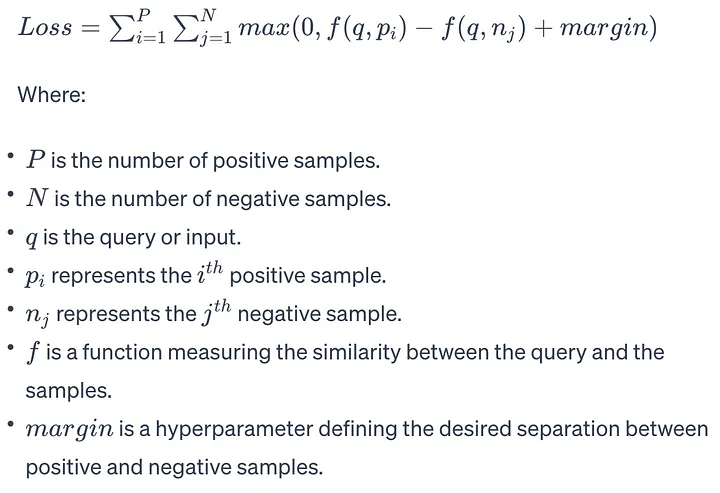

Берём только (query, positive) пары. Это автоматически даёт in-batch negatives.

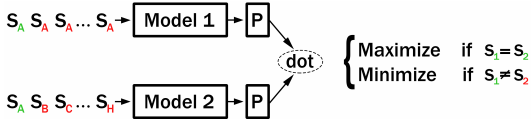

In [ ]:
def make_positive_pairs_for_mnr(dataset: Dataset):
    rows = []
    for x in dataset:
        rows.append({
            "anchor": e5_query(x["query"]),
            "positive": e5_passage(x["positive"]),
        })
    return Dataset.from_list(rows)

mnr_train = make_positive_pairs_for_mnr(base_train)
mnr_dev = make_positive_pairs_for_mnr(base_dev)

len(mnr_train), mnr_train[0]

(7813,
 {'anchor': 'query: Есть ли риски, если собственники имеют детей, не прописанных в квартире?\n\nЧТО нужно проверить и на что обратить внимание при покупке такой квартиры. Квартира была приватизированна в 93 г. на 4 х человек (отец, мать, сын, невестка) равными долями. Все прописаны в квартире.  В 98 м и 99 годах у сына и невестки родились дети, они также прописаны в квартире. Отец+мать и сын+невестка+дети расселяются в 2 квартиры. Есть ли риски, если собственники имеют детей, не прописанных в квартире?',
  'positive': 'passage: Главное, чтобы сделки по продаже и покупке осуществлялись одновременно.Раз Вы покупаете квартиру не свободную от зарегистрированных в ней лиц, то предусмотрите в договоре срок,в который квартира должна быть освобождена от зарегистрированных в ней лиц.Лучше, когда окончательный расчёт по деньгам будет произведён после полного освобождения квартиры.Обязательно убедитесь в том, что имеется по конкретному варианту согласие администрации муниципального образов

In [ ]:
base_model_name = "intfloat/multilingual-e5-large-instruct"

model_mnr = build_st_4bit(base_model_name, max_seq_length=256)
model_mnr.max_seq_length = 256
model_mnr = apply_qlora(
    model_mnr,
    r=8,
    alpha=16,
    dropout=0.05,
    target_modules=["query", "key", "value", "dense"],
)

loss_mnr = MultipleNegativesRankingLoss(model_mnr)

evaluator = EmbeddingSimilarityEvaluator(
    sentences1=pairs_dev["text1"],
    sentences2=pairs_dev["text2"],
    scores=[float(s) for s in pairs_dev["score"]],
    name="9111-dev-spearman"
)

args = SentenceTransformerTrainingArguments(
    output_dir="./e5-9111-mnr",
    num_train_epochs=2,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    warmup_ratio=0.05,
    weight_decay=0.01,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=10,
    save_strategy="steps",
    save_steps=10,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="9111-dev-spearman_spearman_cosine",
    greater_is_better=True,
    optim="paged_adamw_8bit",
)

trainer = SentenceTransformerTrainer(
    model=model_mnr,
    args=args,
    train_dataset=mnr_train,
    loss=loss_mnr,
    evaluator=evaluator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

trainable params: 3,555,328 || all params: 563,445,760 || trainable%: 0.6310


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


...

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights: 0it [00:00, ?it/s]

XLMRobertaModel LOAD REPORT from: ./e5-9111-mnr/checkpoint-120
Key                                                                                  | Status     | 
-------------------------------------------------------------------------------------+------------+-
base_model.model.encoder.layer.{0...23}.intermediate.dense.lora_B.default.weight     | UNEXPECTED | 
base_model.model.encoder.layer.{0...23}.attention.self.value.lora_A.default.weight   | UNEXPECTED | 
base_model.model.encoder.layer.{0...23}.attention.output.dense.lora_B.default.weight | UNEXPECTED | 
base_model.model.encoder.layer.{0...23}.intermediate.dense.lora_A.default.weight     | UNEXPECTED | 
base_model.model.encoder.layer.{0...23}.output.dense.lora_B.default.weight           | UNEXPECTED | 
base_model.model.encoder.layer.{0...23}.attention.self.key.lora_A.default.weight     | UNEXPECTED | 
base_model.model.encoder.layer.{0...23}.attention.self.query.lora_B.default.weight   | UNEXPECTED | 
base_model.model.encoder.lay

TrainOutput(global_step=124, training_loss=2.225838288184135, metrics={'train_runtime': 12179.9845, 'train_samples_per_second': 1.283, 'train_steps_per_second': 0.01, 'total_flos': 0.0, 'train_loss': 2.225838288184135, 'epoch': 2.0})

In [ ]:
after_mnr_metrics = evaluate_paraphrase_threshold(model_mnr, pairs_dev, pairs_test, batch_size=64)
print("BASE:", baseline_metrics)
print("MNR :", after_mnr_metrics)

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

BASE: {'dev_spearman': 0.7516114800886461, 'test_spearman': 0.7512415332815526, 'best_threshold_dev': 0.8889632107023413, 'test_accuracy': 0.8715992037159921, 'test_f1': 0.8103870651641353}
MNR : {'dev_spearman': 0.7736934582062571, 'test_spearman': 0.7719574663895467, 'best_threshold_dev': 0.7675585284280937, 'test_accuracy': 0.8858659588586596, 'test_f1': 0.8361904761904762}


### Анализ -  где стало лучше (ожидаем позитивы ближе, hard-neg дальше)

In [ ]:
@torch.no_grad()
def compute_cos_on_pairs(model, pairs_ds: Dataset, batch_size=64):
    emb1 = embed_texts(model, pairs_ds["text1"], batch_size=batch_size)
    emb2 = embed_texts(model, pairs_ds["text2"], batch_size=batch_size)
    return np.sum(emb1 * emb2, axis=1)

In [ ]:
def qualitative_report_on_pairs(model_before, model_after, pairs_ds: Dataset, topk=10):
    cos_b = compute_cos_on_pairs(model_before, pairs_ds)
    cos_a = compute_cos_on_pairs(model_after,  pairs_ds)

    df = pd.DataFrame({
        "pair_type": pairs_ds["pair_type"],
        "score": pairs_ds["score"],
        "text1": pairs_ds["text1"],
        "text2": pairs_ds["text2"],
        "cos_before": cos_b,
        "cos_after": cos_a,
    })
    df["delta"] = df["cos_after"] - df["cos_before"]

    print("positives")
    display(df[df.pair_type=="positive"].sort_values("delta", ascending=False).head(topk)[
        ["delta","cos_before","cos_after","text1","text2"]
    ])

    print("hard negatives")
    display(df[df.pair_type=="hard_negative_sim_title"].sort_values("delta", ascending=True).head(topk)[
        ["delta","cos_before","cos_after","text1","text2"]
    ])

In [ ]:
# база vs MNR
qualitative_report_on_pairs(model_base, model_mnr, pairs_test, topk=10)

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

positives


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,delta,cos_before,cos_after,text1,text2
2765,0.001092,0.926758,0.927850,query: Могут ли ценные бумаги быть использован...,passage: Уважаемая Елена! Поскольку законодате...
647,-0.003505,0.947266,0.943761,query: Моя бабушка подарила мне деньги в мае 2...,passage: Уважаемая Елена!Согласно ст.2 Закона ...
2987,-0.005797,0.948730,0.942933,query: В каком размере уплачивается государств...,passage: За удостоверение завещаний нотариусам...
287,-0.006618,0.924805,0.918187,"query: Какие документы необходимы, и куда их п...",passage: В случае продажи офисных помещений со...
2010,-0.007589,0.944336,0.936747,query: Есть ли все сделать без уведомления.\n\...,"passage: Уважаемая Юлия Геннадьевна, при решен..."
1290,-0.010495,0.919922,0.909427,query: Ситуация: мой дедушка (89 лет) неизлечи...,"passage: После смерти дедушки, принадлежащая е..."
1035,-0.012011,0.940918,0.928907,query: Прошу дополнительно разъяснить пункт о ...,passage: Уважаемый Андрей! В данном случае Вы ...
598,-0.012739,0.910156,0.897417,query: Каким образом должны быть оформлены отн...,passage: Уважаемая Инна!Попробуйте оформить эт...
1228,-0.013687,0.952637,0.938950,query: Должно ли юридическое лицо уплачивать н...,passage: Приобретение наличной иностранной вал...
1344,-0.013871,0.946289,0.932418,query: Могу ли я Получить Российское гражданст...,passage: Уважаемый Георгий!Вы не только можете...


hard negatives


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,delta,cos_before,cos_after,text1,text2
1485,-0.305855,0.789551,0.483696,query: И смогу ли я потом продать свою собстве...,"passage: Уважаемый Олег! Брак, зарегистрирован..."
1854,-0.302432,0.797363,0.494931,"query: Могу ли я купить квартиру, если один из...",passage: Уважаемый Андрей!Вопросы планировки и...
2232,-0.299831,0.802734,0.502903,query: Эти полдома по наследству достались бра...,passage: Регистрационный учет (ранее- прописка...
1430,-0.295660,0.798340,0.502680,query: Подскажите могу ли я оттянуть уплату шт...,passage: Каждый из братьев собственник своей ч...
897,-0.293024,0.772461,0.479437,query: Как получить лицензию на торговлю и раз...,passage: Для ответа на вопрос нужно знать метр...
1557,-0.292348,0.797363,0.505015,"query: Если да, то на основании чего, если нет...","passage: Уважаемая Ирина! Действительно, в слу..."
1015,-0.292180,0.801758,0.509578,query: Имеет ли по нему право наследования дол...,passage: Инвестор не имеет право навязывать Ва...
1250,-0.291692,0.827148,0.535457,query: Имеет ли она право сдавать свою комнату...,passage: Уважаемая Юлия! До 31.12.01.собесы пр...
1201,-0.290468,0.800781,0.510313,query: Возможна ли продажа этой квартиры без п...,passage: В соответствии с Федеральным законом ...
1728,-0.288758,0.814453,0.525695,"query: Если нужно идти на уступки, то наверно ...",passage: Федеральный закон от 17 декабря 2001 ...
